In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


/usr/local/lib/python3.11/site-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# ==========================================
# 1. 数据准备 (Data Preparation)
dataset = pd.read_csv("LBMA-GOLD.csv", index_col=0)
print("检查原始数据是否有空值:", dataset.isnull().values.any()) 

# 如果输出 True，说明数据里有空洞，必须清洗！
if dataset.isnull().values.any():
    print("发现脏数据！正在剔除空行...")
    dataset = dataset.dropna() # 删掉所有包含空值的行
    print("清洗完成。")
    dataset.to_csv("LBMA-GOLD_cleaned.csv") 
    print("成功！已将清洗后的数据保存为 'LBMA-GOLD_cleaned.csv'")
# print(dataset.shape)
# print(dataset)
# 设置训练集长度 
training_len = len(dataset) - 300

# 获取训练集和测试集原始数据
training_set = dataset.iloc[:training_len, [0]].values#因为只有一列
test_set = dataset.iloc[training_len:, [0]].values

# 标准化
sc = StandardScaler()
train_set_scaled = sc.fit_transform(training_set)
# 注意：测试集只能用训练集的参数 transform，不能 fit
test_set_scaled = sc.transform(test_set) 

# 制作时间序列数据 (Sliding Window = 5或者20)步长
def create_sequences(data, window=5):
    x, y = [], []
    for i in range(window, len(data)):
        x.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

window_size = 120
x_train, y_train = create_sequences(train_set_scaled, window_size)
# 测试集构建时，通常需要保留一部分历史数据来预测第一个点，这里简化逻辑跟随原代码
x_test, y_test = create_sequences(test_set_scaled, window_size)
print(x_train.shape)
# 转换为 PyTorch 张量
# LSTM 要求输入形状: [Batch Size, Sequence Length, Input Size]因为每5天预测下一天，就作为lstm的输入
x_train_tensor = torch.from_numpy(x_train).float().unsqueeze(-1) # 增加特征维度 -> [N, 5, 1]
y_train_tensor = torch.from_numpy(y_train).float().unsqueeze(-1) # -> [N, 1]
x_test_tensor = torch.from_numpy(x_test).float().unsqueeze(-1)
y_test_tensor = torch.from_numpy(y_test).float().unsqueeze(-1)

# 创建 DataLoader (用于 batch 训练)
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)#打包一起（x1,y1)类似
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)#一次拿128个（x,y),且打乱顺序

检查原始数据是否有空值: False
(12213, 120)


In [3]:
# ==========================================
# 2. 模型搭建 (Model Architecture)
# ==========================================

class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        """
        本次搭建的是lstm -->lstm-->relu-->liner-->liner
        修改为lstm -->lstm-->liner
        """
        # Layer 1: LSTM (Input=1 -> Hidden=200)
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=100, batch_first=True)
        # Layer 2: LSTM (Hidden=100 -> Hidden=200)
        # (这里我们只取最后一个时间步，因为这里下一层为全连接层)
        self.lstm2 = nn.LSTM(input_size=100, hidden_size=200, batch_first=True)
        self.fc = nn.Linear(200, 1)

    def forward(self, x):
        # x shape: [Batch, 5, 1]
        
        # passing through LSTM 1
        # out shape: [Batch, 5, 100]
        out, _ = self.lstm1(x) 
        
        # passing through LSTM 2
        # out shape: [Batch, 5, 200]
        out, _ = self.lstm2(out)
        
        # 取最后一个时间步: [Batch,步长也就是seqlenth, 200]，故取-1，代表最后一个步子
        out = out[:, -1, :] 
        out = self.fc(out)
        return out

# 初始化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel().to(device)

In [4]:
def print_layer_parameters(model):
    print(f"{'Layer Name':<15} | {'Parameters':<10} | {'Shape (Weight/Bias)'}")
    print("-" * 60)
    
    total_params = 0
    # 遍历你在 __init__ 中定义的每一层 (module)
    for name, module in model.named_children():
        # 计算该层的参数总量
        layer_params = sum(p.numel() for p in module.parameters())
        total_params += layer_params
        
        print(f"{name:<15} | {layer_params:<10} | ", end="")
        
        # 顺便打印一下这一层里具体张量的形状（比如 100x200 这种）这里的张亮形式是[输出*4，输入]
        shapes = []
        for p_name, p in module.named_parameters():
            shapes.append(str(list(p.shape)))
        print(", ".join(shapes[:1]) + "...") # 只显示第一个形状避免太长
        
    print("-" * 60)
    print(f"{'Total Trainable Params':<25} {total_params}")

# === 使用方法 ===
print_layer_parameters(model)

Layer Name      | Parameters | Shape (Weight/Bias)
------------------------------------------------------------
lstm1           | 41200      | [400, 1]...
lstm2           | 241600     | [800, 100]...
fc              | 201        | [1, 200]...
------------------------------------------------------------
Total Trainable Params    283001


In [5]:
# ==========================================
# 3. 训练配置 (Training Setup)
# ==========================================
#平均绝对误差
criterion = nn.MSELoss()#MSE损失函数
optimizer = optim.Adam(model.parameters(), lr=0.01)#优化器
# mode='min'  : 我们监控的是 Loss，希望它越小越好
# factor=0.5  : 每次触发衰减时，学习率变为原来的 0.5 倍 (0.001 -> 0.0005)
# patience=10 : 如果连续 10 个 Epoch，Loss 都没有明显下降，就触发衰减
# verbose=True: 触发衰减时打印日志
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)



/usr/local/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [6]:
# 记录每个 epoch 的 loss 用于画图
epochs = 500
train_loss_history = []
val_loss_history = []

print("开始训练...")

for epoch in range(epochs):
    # ==========================
    # 1. 训练阶段 (Training)
    # ==========================
    model.train() # 开启训练模式
    epoch_train_loss = 0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
    
    # 计算平均训练 loss
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # ==========================
    # 2. 验证/测试阶段 (Validation)
    # ==========================
    # 这一步是为了给 Scheduler 提供指标，告诉它模型表现如何
    model.eval() # 开启评估模式
    with torch.no_grad():
        # 把整个测试集丢进去算一次 Loss
        # 注意：这里假设 x_test_tensor 已经准备好了
        test_input = x_test_tensor.to(device)
        test_target = y_test_tensor.to(device)
        
        test_pred = model(test_input)
        test_loss = criterion(test_pred, test_target).item()
        val_loss_history.append(test_loss)

    # ==========================
    # 3. 【关键】更新学习率
    scheduler.step(test_loss)

    # ==========================
    # 4. 打印进度
    # ==========================
    if (epoch + 1) % 50 == 0:
        # 获取当前的学习率
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Test Loss: {test_loss:.6f} | "
              f"LR: {current_lr:.6f}") # 打印出来看看有没有衰减

开始训练...
Epoch [50/500] | Train Loss: 0.000408 | Test Loss: 0.000015 | LR: 0.001250
Epoch [100/500] | Train Loss: 0.000390 | Test Loss: 0.000002 | LR: 0.000156
Epoch [150/500] | Train Loss: 0.000375 | Test Loss: 0.000001 | LR: 0.000010
Epoch [200/500] | Train Loss: 0.000374 | Test Loss: 0.000001 | LR: 0.000001
Epoch [250/500] | Train Loss: 0.000372 | Test Loss: 0.000001 | LR: 0.000000
Epoch [300/500] | Train Loss: 0.000372 | Test Loss: 0.000001 | LR: 0.000000
Epoch [350/500] | Train Loss: 0.000372 | Test Loss: 0.000001 | LR: 0.000000
Epoch [400/500] | Train Loss: 0.000378 | Test Loss: 0.000001 | LR: 0.000000
Epoch [450/500] | Train Loss: 0.000373 | Test Loss: 0.000001 | LR: 0.000000
Epoch [500/500] | Train Loss: 0.000373 | Test Loss: 0.000001 | LR: 0.000000


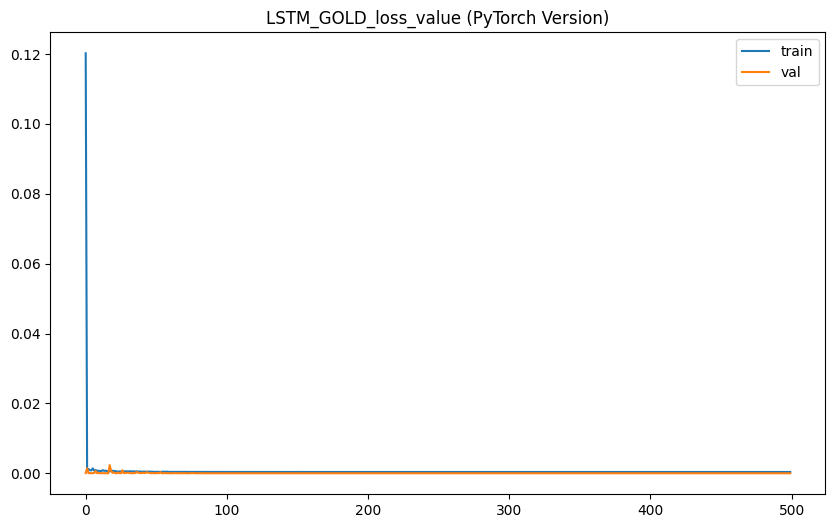

模型已保存为 model.pth


In [7]:
# ==========================================
# 5. 绘图 (Plotting)
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='train')
plt.plot(val_loss_history, label='val')
plt.title("LSTM_GOLD_loss_value (PyTorch Version)")
plt.legend()
plt.show()

# 保存模型
torch.save(model.state_dict(), 'model.pth')
print("模型已保存为 model.pth")

【模型评估结果】
RMSE (均方根误差): 0.3812
MAPE  (平均绝对误差): 0.0062


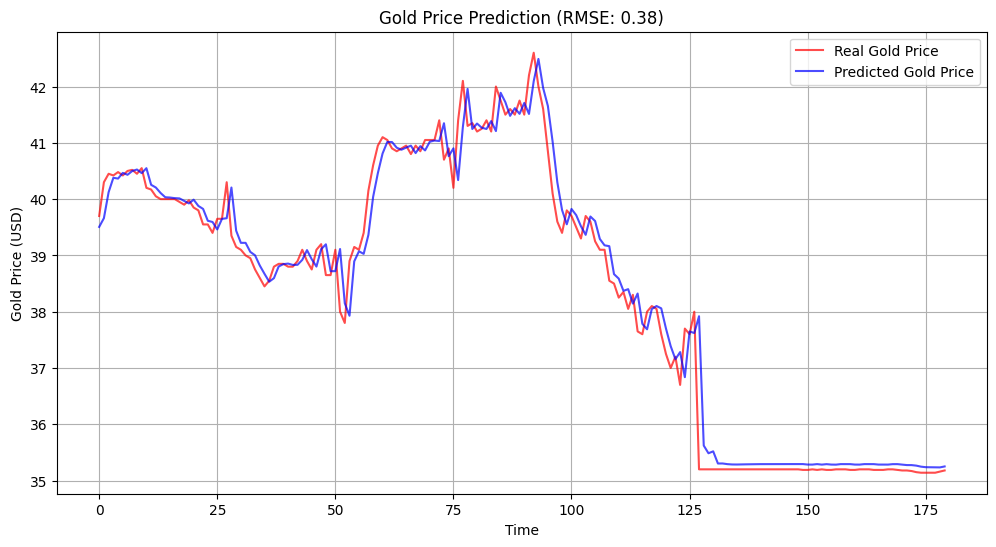

In [8]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

# ==========================================
# 1. 模型预测 (Prediction)
# ==========================================
model.eval() # 切换到评估模式 (关闭 Dropout 等)

# 将测试集放入设备 (GPU/CPU)
x_test_tensor = x_test_tensor.to(device)

# 不计算梯度 (节省内存，加快速度)
with torch.no_grad():
    # 得到模型预测值 (形状是归一化后的 0~1)
    predicted_price = model(x_test_tensor)

# 搬回 CPU 转为 Numpy 方便画图
predicted_price = predicted_price.cpu().numpy()
# print(y_test_tensor.shape)
real_price = y_test_tensor.numpy()
# print(real_price.shape)

# ==========================================
# 2. 数据还原 (Inverse Scaling)
# ==========================================
# 我们之前用了 sc () 把数据压缩到了 0-1
# 现在必须用 sc.inverse_transform 把它还原回真实金价
predicted_price = sc.inverse_transform(predicted_price)
real_price = sc.inverse_transform(real_price)

# ==========================================
# 3. 计算误差指标 (Metrics)
# ==========================================
# RMSE (均方根误差): 值越小越好，表示预测值偏离真实值多少(单位:美元)
rmse = math.sqrt(mean_squared_error(predicted_price,real_price))
# MAE (平均绝对误差): 平均每次预测偏离了多少美元
mape = mean_absolute_percentage_error(real_price, predicted_price)

print(f"【模型评估结果】")
print(f"RMSE (均方根误差): {rmse:.4f}")
print(f"MAPE  (平均绝对误差): {mape:.4f}")

# ==========================================
# 4. 画图对比 (Visualization)
# ==========================================
plt.figure(figsize=(12, 6))

# 画真实值 (红色)
plt.plot(real_price, color='red', label='Real Gold Price', alpha=0.7)
# 画预测值 (蓝色)
plt.plot(predicted_price, color='blue', label='Predicted Gold Price', alpha=0.7)

plt.title(f'Gold Price Prediction (RMSE: {rmse:.2f})')
plt.xlabel('Time')
plt.ylabel('Gold Price (USD)')
plt.legend()
plt.grid(True)
plt.show()